# Event Selection

**_must run with dfs will all reconstructed slices and tracks_**

This notebook runs the full event selection, evaluating selection performance

- makes mode breakdown bar plots for each selection stage
- makes purity/efficiency summary plots

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import sys
from os import path, makedirs
from datetime import datetime
import pickle

# local imports
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.makedf.selections import *
from pyanalib.split_df_helpers import *
from pyanalib.pandas_helpers import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 
from matplotlib.patches import Patch

plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
# turn off RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
syst_tag = ""
ret = get_ana_dfs(option="event_selection", syst_tag = syst_tag)

mc_evt_df, mc_trk_df           = ret["mc"], ret["mc_trk"]
data_evt_df, data_trk_df       = ret["data"], ret["data_trk"]
intime_evt_df, intime_trk_df   = ret["intime"], ret["intime_trk"]
dirt_evt_df, dirt_trk_df       = ret["dirt"], ret["dirt_trk"]
offbeam_evt_df, offbeam_trk_df = ret["offbeam"], ret["offbeam_trk"]

pot_str = ret["pot_str"]
plot_labels_bar = ["Events (POT={})".format(pot_str), "", ""]
plot_labels_hist = ["", "Events (POT={})".format(pot_str), ""]

Keys: ['/evt_0', '/evt_1', '/evt_2', '/evt_3', '/evt_4', '/evt_5', '/hdr_0', '/hdr_1', '/hdr_2', '/hdr_3', '/hdr_4', '/hdr_5', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_2', '/histgenevtdf_3', '/histgenevtdf_4', '/histgenevtdf_5', '/histpotdf_0', '/histpotdf_1', '/histpotdf_2', '/histpotdf_3', '/histpotdf_4', '/histpotdf_5', '/mcnu_0', '/mcnu_1', '/mcnu_2', '/mcnu_3', '/mcnu_4', '/mcnu_5', '/split', '/trk_0', '/trk_1', '/trk_2', '/trk_3', '/trk_4', '/trk_5']
Reading file with tag aa, mc_n_split: 6
Keys: ['/evt_0', '/evt_1', '/evt_2', '/evt_3', '/evt_4', '/evt_5', '/hdr_0', '/hdr_1', '/hdr_2', '/hdr_3', '/hdr_4', '/hdr_5', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_2', '/histgenevtdf_3', '/histgenevtdf_4', '/histgenevtdf_5', '/histpotdf_0', '/histpotdf_1', '/histpotdf_2', '/histpotdf_3', '/histpotdf_4', '/histpotdf_5', '/mcnu_0', '/mcnu_1', '/mcnu_2', '/mcnu_3', '/mcnu_4', '/mcnu_5', '/split', '/trk_0', '/trk_1', '/trk_2', '/trk_3', '/trk_4', '/trk_5']
Reading file w

In [4]:
# calculate TKI for reco slices
def add_cc1p0pi_tki(df):
    tki_var_names = ["del_alpha", "del_phi", "del_Tp", "del_p", "del_Tp_x", "del_Tp_y"]

    slc_mudf = df.mu.pfp.trk
    slc_pdf = df.p.pfp.trk
    slc_P_mu_col = pad_column_name(("P", "p_muon"), slc_mudf)
    slc_P_p_col = pad_column_name(("P", "p_proton"), slc_pdf)
    tki_reco = get_cc1p0pi_tki(slc_mudf, slc_pdf, slc_P_mu_col, slc_P_p_col)
    for var_name in tki_var_names:
        df = multicol_add(df, tki_reco[var_name].rename(var_name))
    return df

def add_opening_angle(df, truth=False, nu=False):
    if nu:
        opening_angle = (
            df.mc.mu.dir[["x", "y", "z"]].values * df.mc.p.dir[["x", "y", "z"]].values
        ).sum(axis=1)

        df["theta_mu_p"] = np.arccos(opening_angle) * 180. / np.pi

    elif truth:
        opening_angle = (
            df.mc.mu.dir[["x", "y", "z"]].values * df.mc.p.dir[["x", "y", "z"]].values
        ).sum(axis=1)

        df["mc_theta_mu_p"] = np.arccos(opening_angle) * 180. / np.pi


    else:
        opening_angle = (
            df.mu.pfp.trk.dir[["x", "y", "z"]].values * df.p.pfp.trk.dir[["x", "y", "z"]].values
        ).sum(axis=1)

        df["theta_mu_p"] = np.arccos(opening_angle) * 180. / np.pi
    return df

# mc_df, data_df, intime_df, dirt_df = (
#     add_cc1p0pi_tki(df)
#     for df in (mc_df, data_df, intime_df, dirt_df)
# )

# mc_df, data_df, intime_df, dirt_df = (
#     add_opening_angle(df)
#     for df in (mc_df, data_df, intime_df, dirt_df)
# )

# mc_evt_df = add_opening_angle(mc_evt_df, truth=True)
# mc_evt_df = add_opening_angle(mc_evt_df)

In [5]:
save_fig = True
save_nevts = True
show_plot = True

save_fig_base_dir = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, f"event_selection-{syst_tag}-{today_str}")

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)



save_nevts_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10/nevts"
if save_nevts:
    if not path.exists(save_nevts_dir):
        makedirs(save_nevts_dir)
    print("saving nevts in ", save_nevts_dir)

saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/event_selection--20260326
saving nevts in  /exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10/nevts


In [6]:
# for event selection summary plot
breakdown_dict = {"topology": {}, "genie": {}}

# save dfs per stage, df_dict used for efficiency plot
df_dict = {} 
df_dict_data = {}
df_dict_intime = {} 
df_dict_offbeam = {}
df_dict_dirt = {}

# Event Selection

In [7]:
def plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=True):

    ret_dict = {}

    for bar_type in ["topology", "genie"]: # "nu_cosmics"
        save_name = save_fig_dir + "/bar_plot-{}-{}.png".format(bar_type, stage_key)
        this_ret = bar_plot(breakdown_type=bar_type,
                            mc_df=mc_df, intime_df=intime_df, dirt_df=dirt_df,
                            show_plot=show_plot, plot_labels=plot_labels_bar,
                            save_fig=save_fig, save_name=save_name)
        ret_dict[bar_type] = this_ret

    return ret_dict

## Cosmic Rejection

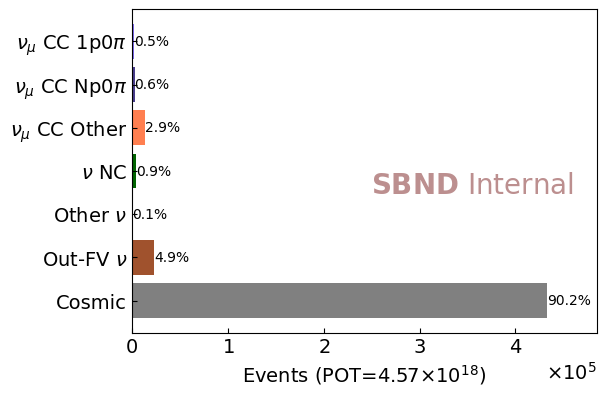

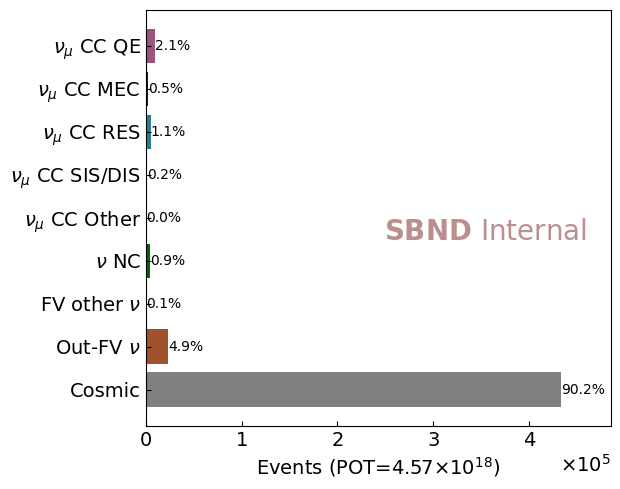

In [8]:
stage_key = "allreco"

mc_df     = mc_evt_df
data_df   = data_evt_df
intime_df = intime_evt_df
offbeam_df = offbeam_evt_df
dirt_df   = dirt_evt_df

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [9]:
this_key = "allreco"
mc_df = df_dict[this_key]
data_df = df_dict_data[this_key]
intime_df = df_dict_intime[this_key]
offbeam_df = df_dict_offbeam[this_key]
dirt_df = df_dict_dirt[this_key]

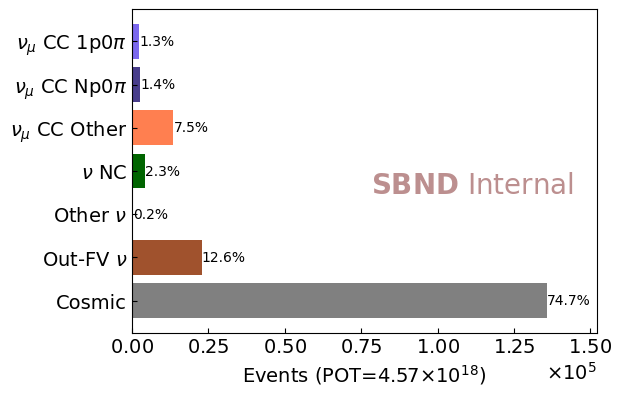

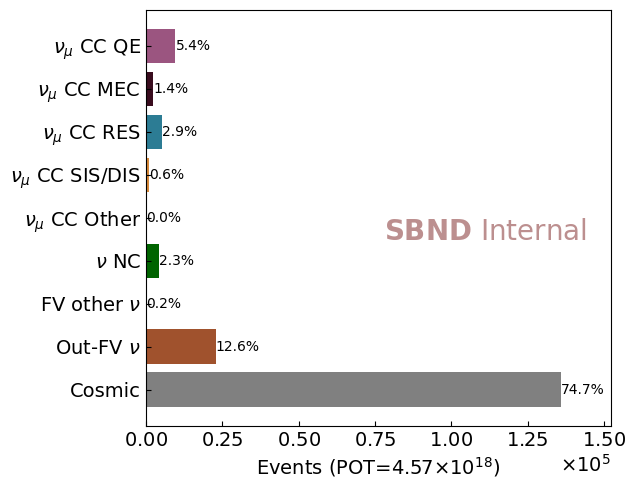

In [10]:
stage_key = "is_clear_cosmic"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_clear_cosmic(df)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

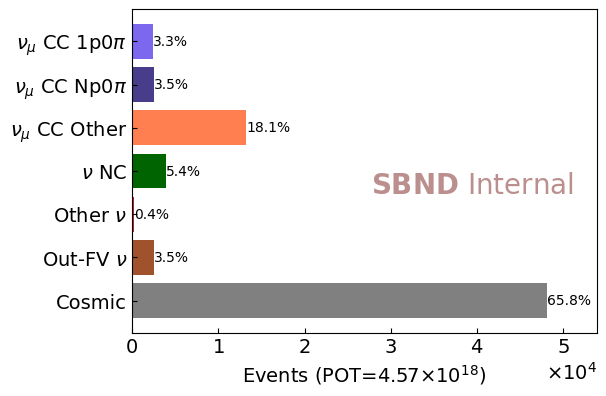

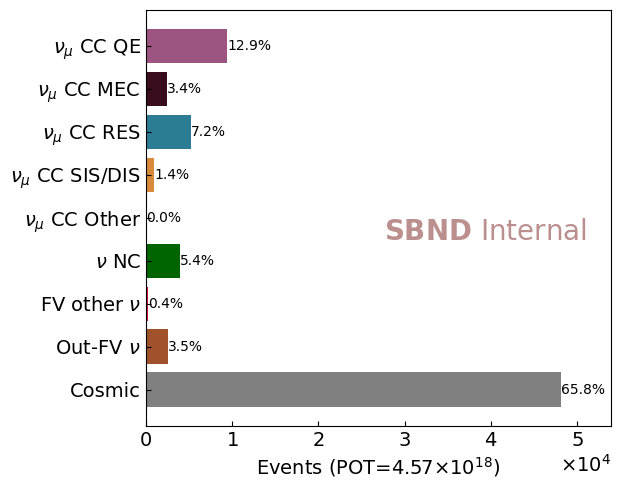

In [11]:
stage_key = "vertex_in_fv"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_vertex_in_fv(df, det=DETECTOR)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

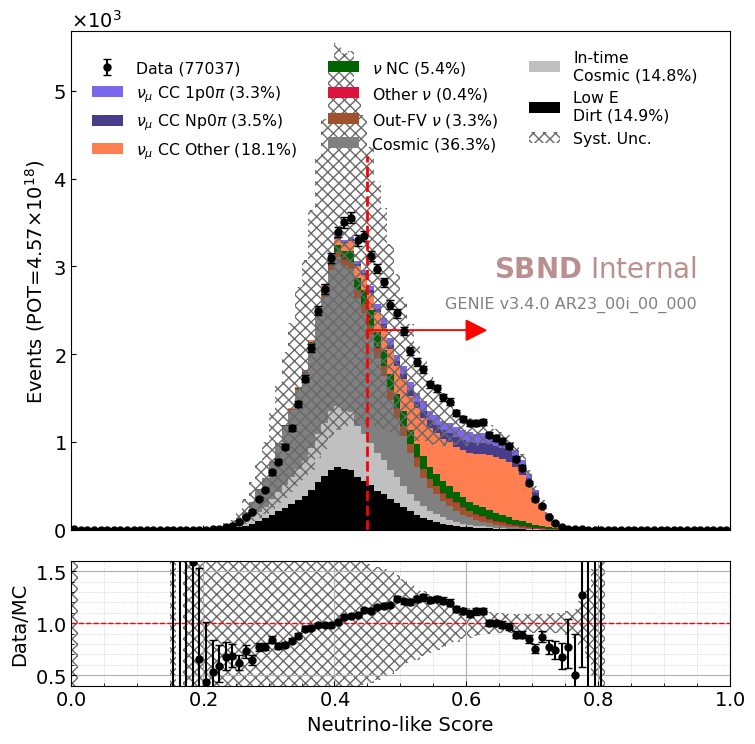

In [14]:
var_config = VariableConfig.nu_score()
plot_labels = [var_config.var_labels[0], "Events (POT={})".format(pot_str), ""]

for plot_type in ["topology"]: #, "genie"]:
    save_name = save_fig_dir + "/selected-{}_{}.png".format(var_config.var_save_name, plot_type)
    ret_hist_topo = overlay_hists(plot_type,
                                  mc_df=mc_df, 
                                  data_df=data_df, 
                                  intime_df=intime_df, 
                                  dirt_df=dirt_df,
                                  syst=get_frac_unc(mc_df, intime_df, offbeam_df, var_config),
                                  ratio=True,
                                  ax_ylim_ratio=1.7,
                                  vline=[[NU_SCORE_TH, 1]],
                                  var_config=var_config,
                                  plot_labels=plot_labels,
                                  save_fig=save_fig, 
                                  save_name=save_name)

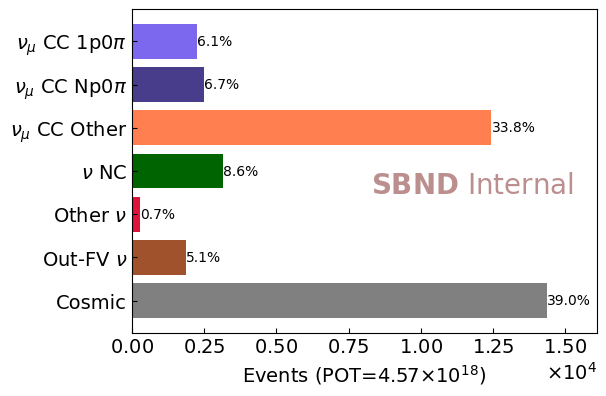

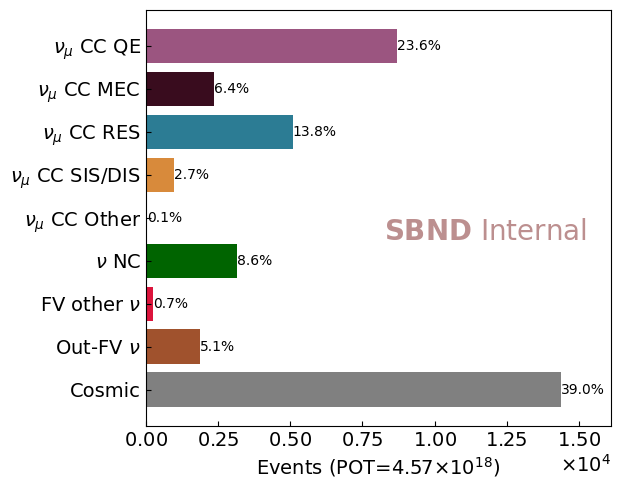

In [15]:
stage_key = "nu_score"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_nu_score(df, NU_SCORE_TH)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [16]:
# dirt_trk_df_ = dirt_trk_df

## Slice has two tracks

In [17]:
# TODO: this is for det var samples
# TODO: move to dfmaker

chimu_avg = avg_chi2(mc_trk_df, "chi2_muon")
mc_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(mc_trk_df, "chi2_proton")
mc_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(data_trk_df, "chi2_muon")
data_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(data_trk_df, "chi2_proton")
data_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(intime_trk_df, "chi2_muon")
intime_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(intime_trk_df, "chi2_proton")
intime_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(offbeam_trk_df, "chi2_muon")
offbeam_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(offbeam_trk_df, "chi2_proton")
offbeam_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(dirt_trk_df, "chi2_muon")
dirt_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(dirt_trk_df, "chi2_proton")
dirt_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

In [18]:
# dirt_trk_df_ = dirt_trk_df

In [19]:
mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    get_valid_trks(df)
    for df in (mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df)
)

mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    match_trkdf_to_slcdf(trk_df, df)
    for trk_df, df in ((mc_trk_df, mc_df), (data_trk_df, data_df), (intime_trk_df, intime_df), (offbeam_trk_df, offbeam_df), (dirt_trk_df, dirt_df))
)

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    get_trk_info(df, trk_df, SAVE_NTRKS)
    for df, trk_df in ((mc_df, mc_trk_df), (data_df, data_trk_df), (intime_df, intime_trk_df), (offbeam_df, offbeam_trk_df), (dirt_df, dirt_trk_df))
)

/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/makedf/selections.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evtdf["n_trks"] = ntrks
/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/makedf/selections.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evtdf["n_good_trks"] = ntrks
/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/makedf/selections.py:51: SettingWithCopyWarn

no syst provided


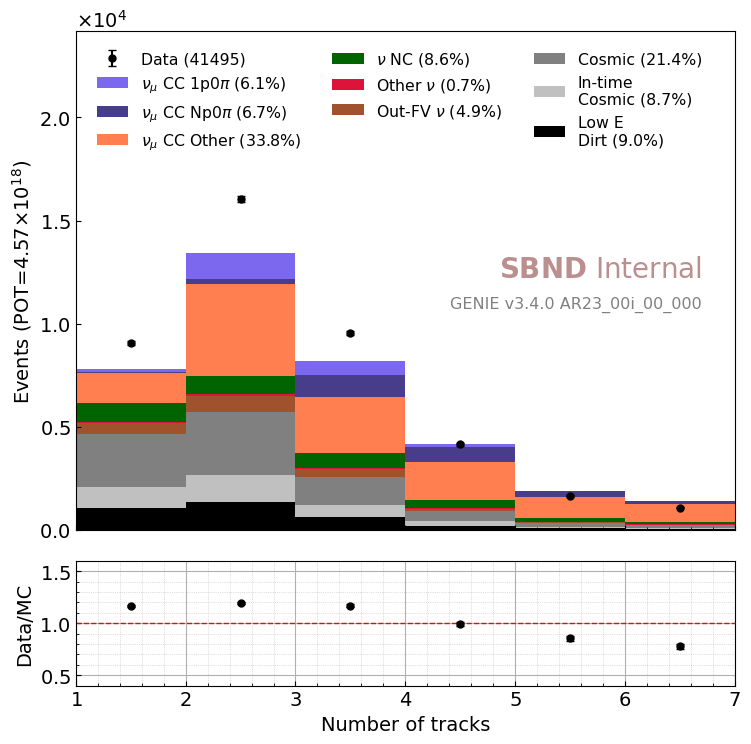

no syst provided


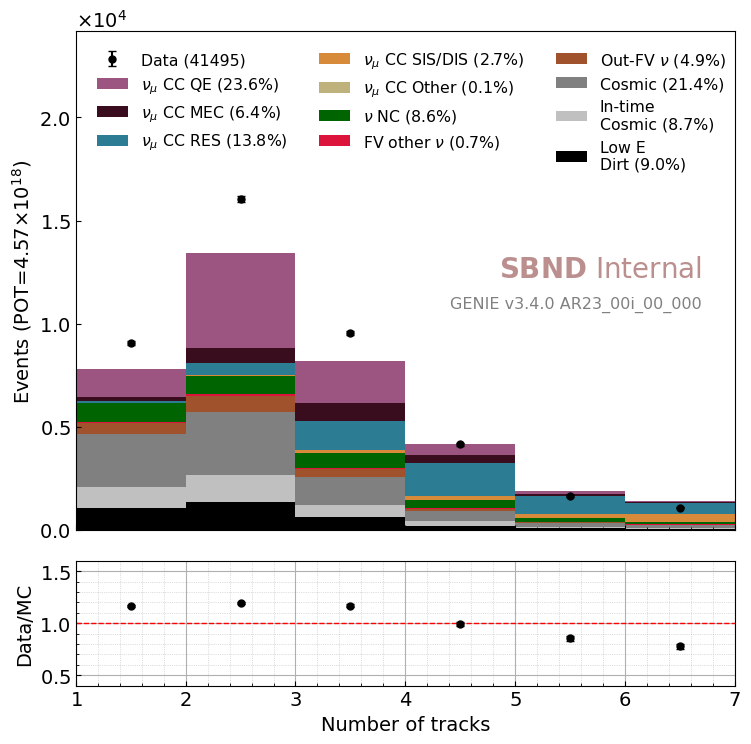

In [20]:
var_config = VariableConfig.n_trks()
plot_labels = ["Number of tracks", "Events (POT={})".format(pot_str), ""]

for plot_type in ["topology", "genie"]:
    save_name = save_fig_dir + "/selected-{}_{}.png".format("ntrks", plot_type)
    ret_hist_topo = overlay_hists(plot_type,
                                  mc_df=mc_df, 
                                  data_df=data_df, 
                                  intime_df=intime_df, 
                                  dirt_df=dirt_df,
                                  ratio=True,
                                  ax_ylim_ratio=1.8,
                                  var_config=var_config,
                                  plot_labels=plot_labels,
                                  save_fig=save_fig, 
                                  save_name=save_name)

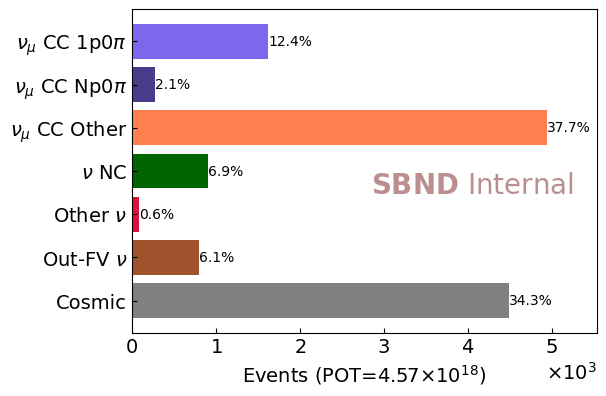

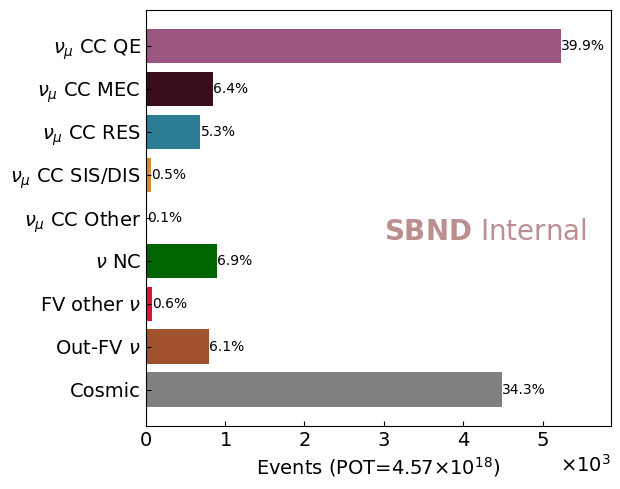

In [21]:
stage_key = "2prong"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_2prong(df)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, None, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

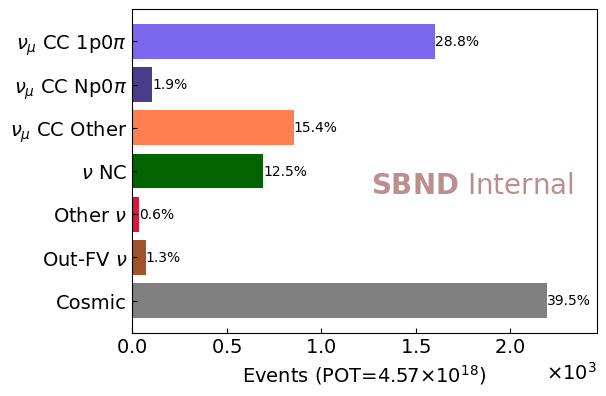

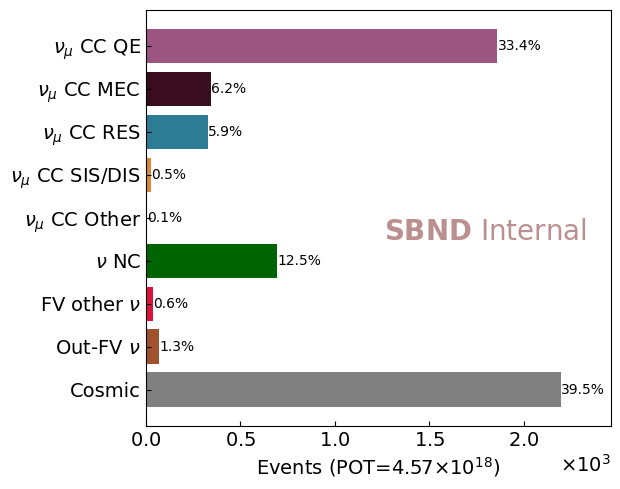

In [22]:
stage_key = "2prong-contained"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_2prong_contained(df, det=DETECTOR)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [23]:
# copy mc info & weights to trkdfs to make the plotter work
# TODO: make this more efficient
for syst in ["G4", "GENIE", "Flux"]:
    for i in tqdm(range(100)):
        mc_df[("trk1", "mc", syst, "univ_{}".format(i), "", "", "")] = mc_df["mc"][syst]["univ_{}".format(i)]
        mc_df[("trk2", "mc", syst, "univ_{}".format(i), "", "", "")] = mc_df["mc"][syst]["univ_{}".format(i)]

mc_df[("trk1", "mc", "pdg", "", "", "", "")] = mc_df["mc"]["pdg"]
mc_df[("trk2", "mc", "pdg", "", "", "", "")] = mc_df["mc"]["pdg"]

  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_45747/1342490075.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_df[("trk1", "mc", syst, "univ_{}".format(i), "", "", "")] = mc_df["mc"][syst]["univ_{}".format(i)]
/tmp/ipykernel_45747/1342490075.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_df[("trk2", "mc", syst, "univ_{}".format(i), "", "", "")] = mc_df["mc"][syst]["univ_{}".format(i)]
/tmp/ipykernel_45747/1342490075.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy 

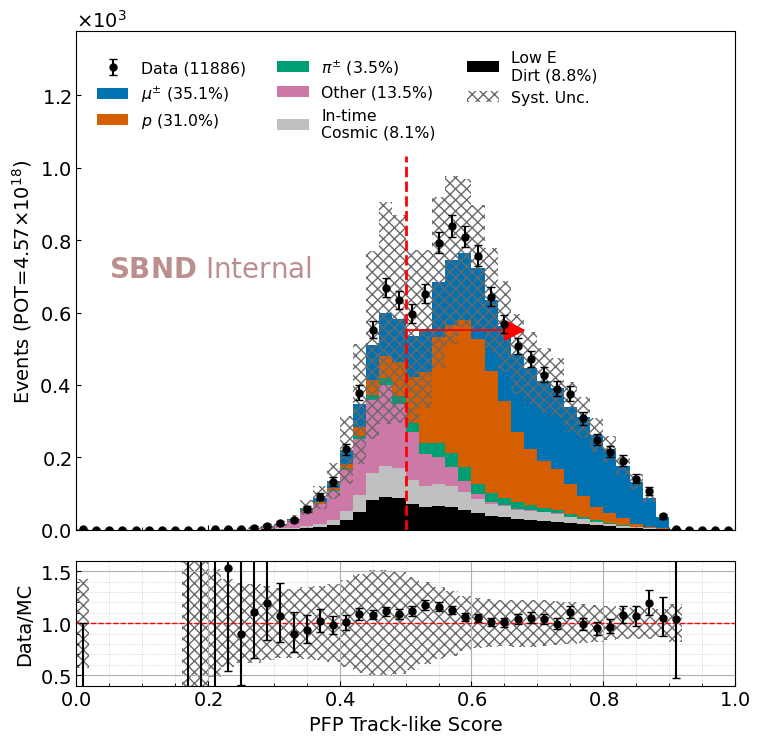

In [25]:
plot_type = "pdg"

mc_trk_df = pd.concat([mc_df.trk1, mc_df.trk2])
data_trk_df = pd.concat([data_df.trk1, data_df.trk2])
intime_trk_df = pd.concat([intime_df.trk1, intime_df.trk2])
offbeam_trk_df = pd.concat([offbeam_df.trk1, offbeam_df.trk2])
dirt_trk_df = pd.concat([dirt_df.trk1, dirt_df.trk2])

var_config = VariableConfig.track_score()

plot_labels = [var_config.var_labels[0], "Events (POT={})".format(pot_str), ""]
save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist = overlay_hists(plot_type,
                         mc_df=mc_trk_df, 
                         data_df=data_trk_df, 
                         intime_df=intime_trk_df, 
                         dirt_df=dirt_trk_df,
                         syst=get_frac_unc(mc_trk_df, intime_trk_df, offbeam_trk_df, var_config),
                         ratio=True,
                         ax_ylim_ratio=1.8,
                         vline=[[0.5, 1]],
                         var_config=var_config,
                         plot_labels=plot_labels,
                         save_fig=save_fig, 
                         save_name=save_name)

with open(f'{save_nevts_dir}/{syst_tag}_{var_config.var_save_name}.pkl', 'wb') as f:
    pickle.dump(ret_hist, f)

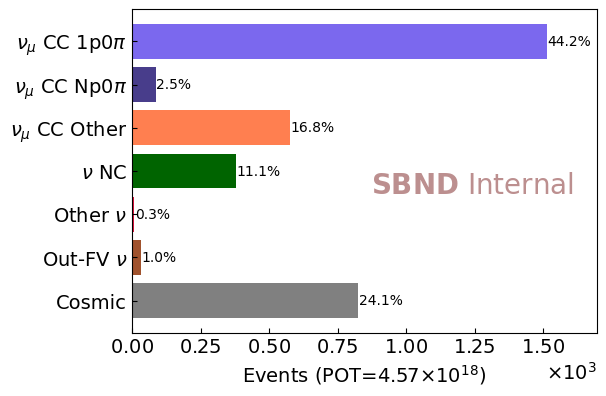

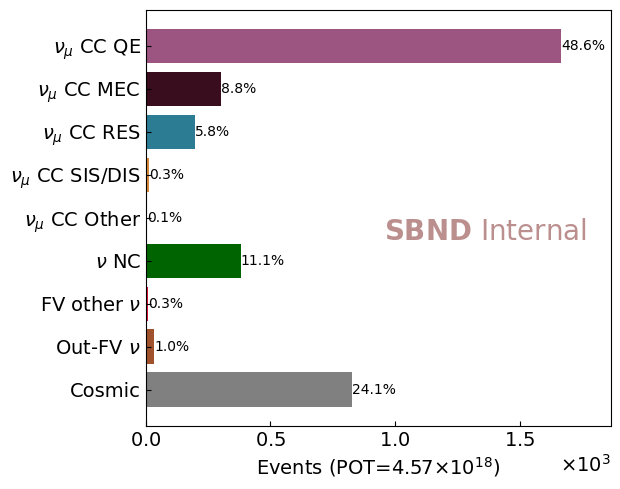

In [26]:
stage_key = "2prong-trackscore"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_2prong_trackscore(df, TRACKSCORE_TH)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

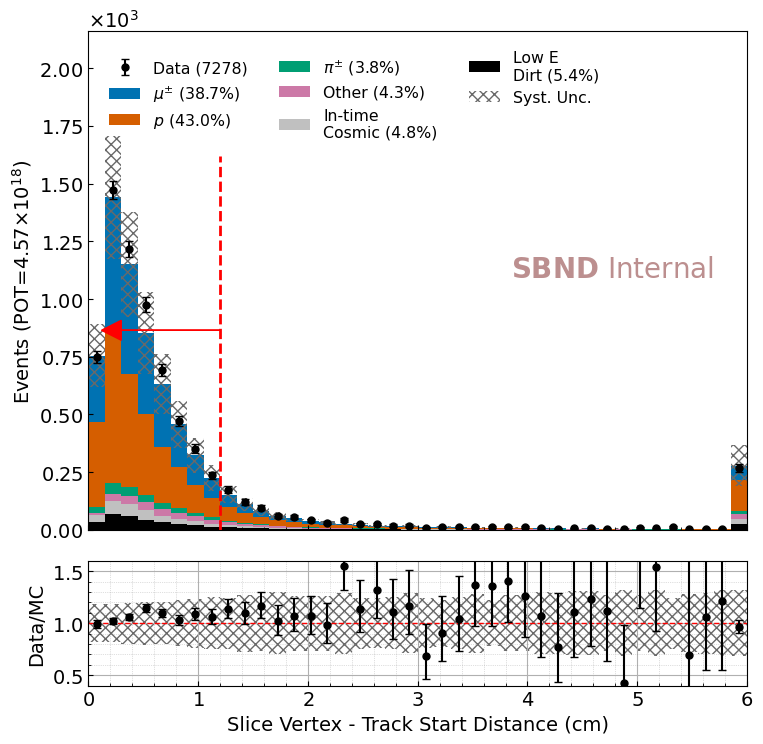

In [27]:
plot_type = "pdg"

mc_trk_df = pd.concat([mc_df.trk1, mc_df.trk2])
data_trk_df = pd.concat([data_df.trk1, data_df.trk2])
intime_trk_df = pd.concat([intime_df.trk1, intime_df.trk2])
offbeam_trk_df = pd.concat([offbeam_df.trk1, offbeam_df.trk2])
dirt_trk_df = pd.concat([dirt_df.trk1, dirt_df.trk2])

var_config = VariableConfig.vtx_dist()

plot_labels = [var_config.var_labels[0], "Events (POT={})".format(pot_str), ""]
save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist = overlay_hists(plot_type,
                                mc_df=mc_trk_df, 
                                data_df=data_trk_df, 
                                intime_df=intime_trk_df, 
                                dirt_df=dirt_trk_df,
                                syst=get_frac_unc(mc_trk_df, intime_trk_df, offbeam_trk_df, var_config),
                                ratio=True,
                                vline=[[VTXDIST_TH, 0]],
                                var_config=var_config,
                                plot_labels=plot_labels,
                                save_fig=save_fig, 
                                save_name=save_name)

with open(f'{save_nevts_dir}/{syst_tag}_{var_config.var_save_name}.pkl', 'wb') as f:
    pickle.dump(ret_hist, f)

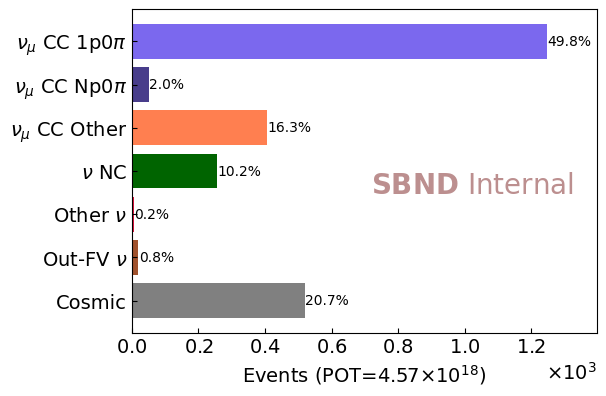

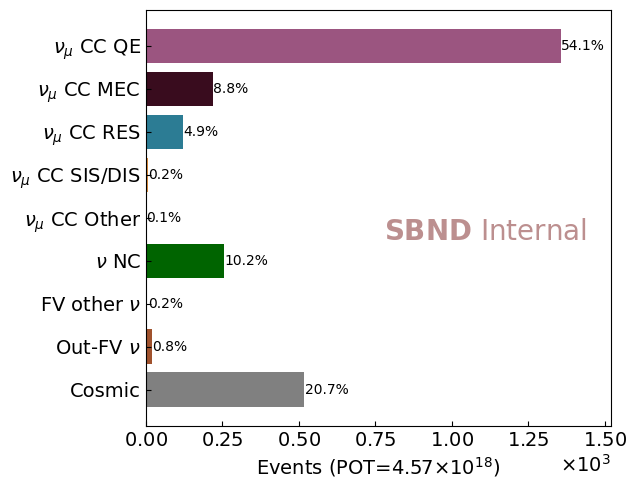

In [28]:
stage_key = "2prong-vtxdist"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_2prong_vtxdist(df, VTXDIST_TH)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

## PID

Percentage of tracks with score = 0: 0.0465881652498925
Percentage of tracks with score = 0: 0.05203750868256541
Percentage of tracks with score = 0: 0.04992888565474812
Percentage of tracks with score = 0: 0.0


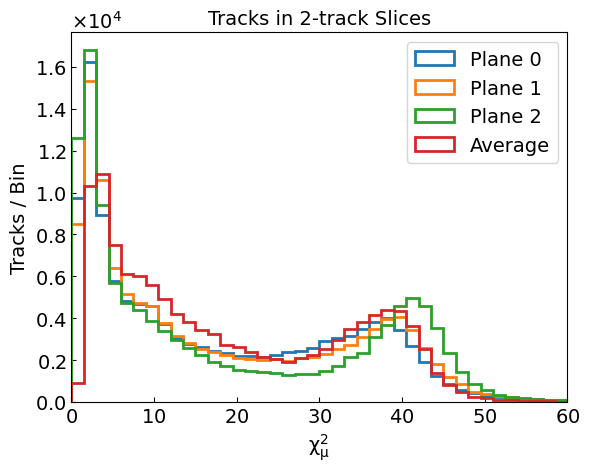

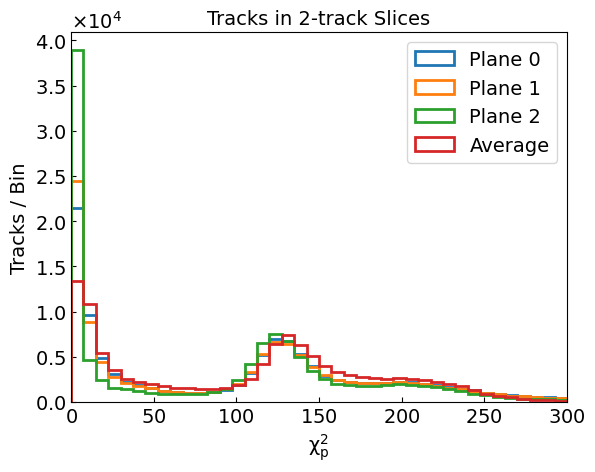

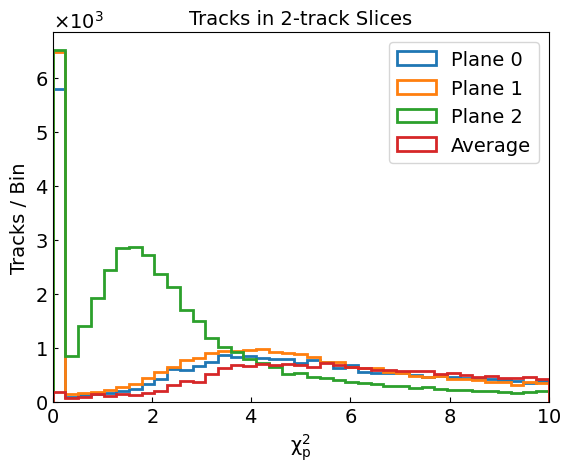

In [29]:
# compare using avg vs. single plane
plabels = ["Plane 0", "Plane 1", "Plane 2", "Average"]

var_config = VariableConfig.chi2_mu()
for ptag, plabel in zip(["I0", "I1", "I2", "avg"], plabels):
    var = mc_trk_df[("pfp", "trk", "chi2pid", ptag, "chi2_muon", "")]
    plt.hist(var, bins=var_config.bins, histtype="step", label=plabel, linewidth=2)

    plt.xlim(var_config.bins[0], var_config.bins[-1])
    plt.xlabel(var_config.var_labels[0])
    plt.ylabel("Tracks / Bin")
    plt.legend()
    plt.title("Tracks in 2-track Slices")

    # percentage of tracks with score = 0
    print(f"Percentage of tracks with score = 0: {np.sum((var == 0) | (var == np.nan)) / len(var)}")

if save_fig:
    plt.savefig(save_fig_dir + f"/{var_config.var_save_name}_plane_comparison.pdf", bbox_inches="tight")
    plt.show()

var_config = VariableConfig.chi2_proton()
for ptag, plabel in zip(["I0", "I1", "I2", "avg"], plabels):
    var = mc_trk_df[("pfp", "trk", "chi2pid", ptag, "chi2_proton", "")]
    plt.hist(var, bins=var_config.bins, histtype="step", label=plabel, linewidth=2)

    plt.xlim(var_config.bins[0], var_config.bins[-1])
    plt.xlabel(var_config.var_labels[0])
    plt.ylabel("Tracks / Bin")
    plt.legend()
    plt.title("Tracks in 2-track Slices")

if save_fig:
    plt.savefig(save_fig_dir + f"/{var_config.var_save_name}_plane_comparison.pdf", bbox_inches="tight")
    plt.show()

var_config = VariableConfig.chi2_proton()
for ptag, plabel in zip(["I0", "I1", "I2", "avg"], plabels):
    var = mc_trk_df[("pfp", "trk", "chi2pid", ptag, "chi2_proton", "")]
    bins = np.linspace(0, 10, 40)
    plt.hist(var, bins=bins, histtype="step", label=plabel, linewidth=2)
    plt.xlim(bins[0], bins[-1])
    plt.xlabel(var_config.var_labels[0])
    plt.ylabel("Tracks / Bin")
    plt.legend()
    plt.title("Tracks in 2-track Slices")

if save_fig:
    plt.savefig(save_fig_dir + f"/{var_config.var_save_name}_plane_comparison_zoom.pdf", bbox_inches="tight")
    plt.show()

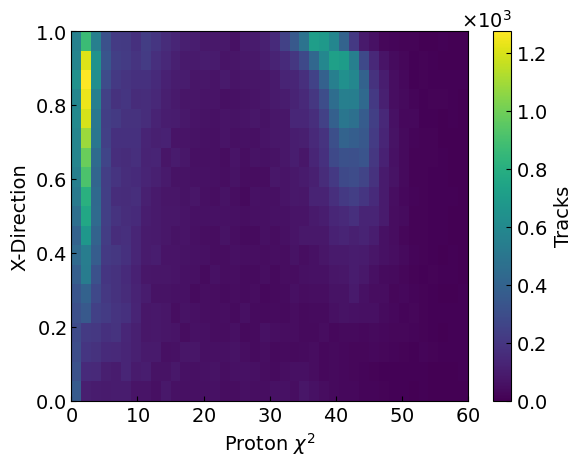

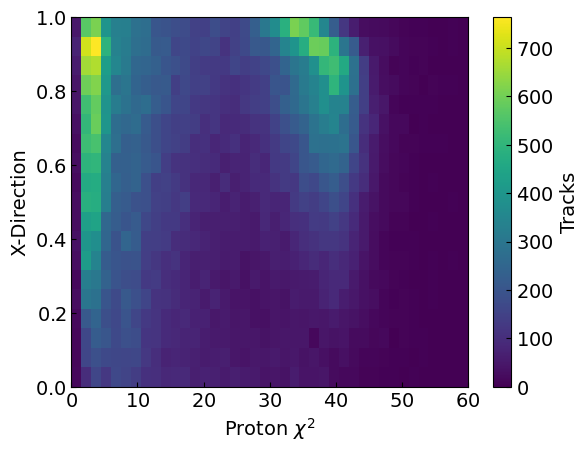

In [33]:
# does this make the behaviour more isotropic?
var1 = mc_trk_df[("pfp", "trk", "chi2pid", "I2", "chi2_muon", "")]
var_config = VariableConfig.chi2_mu()
bins1 = var_config.bins

var2 = mc_trk_df[("pfp", "trk", "dir", "z", "", "")]
bins2 = np.linspace(0, 1, 20)
plt.hist2d(var1, var2, bins=[bins1, bins2])
plt.colorbar(label="Tracks")
plt.xlabel("Proton $\\chi^2$")
plt.ylabel("X-Direction")
plt.show()

var1 = mc_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")]
var_config = VariableConfig.chi2_mu()
bins1 = var_config.bins

var2 = mc_trk_df[("pfp", "trk", "dir", "z", "", "")]
bins2 = np.linspace(0, 1, 20)
plt.hist2d(var1, var2, bins=[bins1, bins2])
plt.colorbar(label="Tracks")
plt.xlabel("Proton $\\chi^2$")
plt.ylabel("X-Direction")
plt.show()

In [ ]:
# all tracks in 2-track slices
plot_type = "pdg"

mc_trk_df = pd.concat([mc_df.trk1, mc_df.trk2])
data_trk_df = pd.concat([data_df.trk1, data_df.trk2])
intime_trk_df = pd.concat([intime_df.trk1, intime_df.trk2])
offbeam_trk_df = pd.concat([offbeam_df.trk1, offbeam_df.trk2])
dirt_trk_df = pd.concat([dirt_df.trk1, dirt_df.trk2])

for var_config in [VariableConfig.trk_len()]: 
                #    VariableConfig.chi2_mu(), 
                #    VariableConfig.chi2_proton()]:

    plot_labels = [var_config.var_labels[0], "Events (POT={})".format(pot_str), ""]
    save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
    ret_hist = overlay_hists(plot_type,
                                    mc_df=mc_trk_df, 
                                    data_df=data_trk_df, 
                                    intime_df=intime_trk_df, 
                                    dirt_df=dirt_trk_df,
                                    syst=get_frac_unc(mc_trk_df, intime_trk_df, offbeam_trk_df, var_config),
                                    ratio=True,
                                    vline=[50],
                                    var_config=var_config,
                                    plot_labels=plot_labels,
                                    save_fig=save_fig, 
                                    save_name=save_name)

    with open(f'{save_nevts_dir}/{syst_tag}_{var_config.var_save_name}.pkl', 'wb') as f:
        pickle.dump(ret_hist, f)


In [ ]:
def get_mcs_range_diff(trks):
    mcs_range_diff = (trks.pfp.trk.rangeP.p_muon - trks.pfp.trk.mcsP.fwdP_muon) / trks.pfp.trk.rangeP.p_muon
    trks[("pfp", "trk", "mcs_range_diff", "", "", "")] = mcs_range_diff
    return trks

mc_trk_df = get_mcs_range_diff(mc_trk_df)
data_trk_df = get_mcs_range_diff(data_trk_df)
intime_trk_df = get_mcs_range_diff(intime_trk_df)
offbeam_trk_df = get_mcs_range_diff(offbeam_trk_df)
dirt_trk_df = get_mcs_range_diff(dirt_trk_df)

In [ ]:
# tracks after len > 50 cm cut for muon selection
def len_cut(trks):
    trks = trks[trks.pfp.trk.len > 50]
    return trks

mc_trk_df = len_cut(mc_trk_df)
data_trk_df = len_cut(data_trk_df)
intime_trk_df = len_cut(intime_trk_df)
offbeam_trk_df = len_cut(offbeam_trk_df)
dirt_trk_df = len_cut(dirt_trk_df)

for var_config in [VariableConfig.mcs_range_diff()]: 

    plot_labels = [var_config.var_labels[0], "Events (POT={})".format(pot_str), ""]
    save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
    ret_hist_chi2mu = overlay_hists(plot_type,
                                    mc_df=mc_trk_df, 
                                    data_df=data_trk_df, 
                                    intime_df=intime_trk_df, 
                                    syst=get_frac_unc(mc_trk_df, intime_trk_df, offbeam_trk_df, var_config),
                                    dirt_df=dirt_trk_df,
                                    ratio=True,
                                    vline=[-QUAL_TH, QUAL_TH],
                                    var_config=var_config,
                                    plot_labels=plot_labels,
                                    save_fig=save_fig, 
                                    save_name=save_name)

    with open(f'{save_nevts_dir}/{syst_tag}_{var_config.var_save_name}-len50cm.pkl', 'wb') as f:
        pickle.dump(ret_hist, f)

In [ ]:
# mc_evt_df.loc[mc_trk_df.index.unique()]
# muon_pid = mc_trk_df.pfp.trk.chi2pid.avg.chi2_muon
# muon_pid.name = ("chi2_muon", "", "", "", "")
# # mc_evt_df = mc_evt_df.join(muon_pid, how="left")
# var = mc_evt_df.chi2_muon
# n_cv, _, _ = plt.hist(var, bins=np.linspace(0, 60, 41), histtype="step", label="MC", linewidth=2)
# n_univs = []
# for i in range(100):
#     weights = mc_evt_df.mc.GENIE["univ_{}".format(i)]
#     # set nan to 1
#     weights = weights.fillna(1)
#     n_univ, _ = np.histogram(var, bins=np.linspace(0, 60, 41), weights=weights)
#     n_univs.append(n_univ)
# plt.show()

# cov_mat = np.cov(np.array(n_univs).T)
# n_cv_safe = np.where(n_cv == 0, 1, n_cv)
# n_cv_safe
# frac_unc_genie = np.sqrt(np.diag(cov_mat / n_cv_safe**2))

# frac_unc = np.sqrt(frac_unc_genie**2 + frac_unc_flux**2 + frac_unc_g4**2)
# frac_unc

In [ ]:
# tracks after quality cut for muon selection
def mcs_range_diff_cut(trks):
    trks = trks[trks.pfp.trk.mcs_range_diff < QUAL_TH]
    return trks

# mc_trk_df = mcs_range_diff_cut(mc_trk_df) 
# data_trk_df = mcs_range_diff_cut(data_trk_df)
# intime_trk_df = mcs_range_diff_cut(intime_trk_df)
# dirt_trk_df = mcs_range_diff_cut(dirt_trk_df)
mc_trk_df_ = mc_trk_df.copy()
data_trk_df_ = data_trk_df.copy()
intime_trk_df_ = intime_trk_df.copy()
offbeam_trk_df_ = offbeam_trk_df.copy()
dirt_trk_df_ = dirt_trk_df.copy()

vline_list = [MU_CHI2MU_TH, MU_CHI2P_TH]
for vidx, var_config in enumerate([VariableConfig.chi2_mu(), VariableConfig.chi2_proton()]):

    plot_labels = [var_config.var_labels[0], "Events (POT={})".format(pot_str), ""]
    save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
    ret_hist_chi2mu = overlay_hists(plot_type,
                                    mc_df=mc_trk_df, 
                                    data_df=data_trk_df, 
                                    intime_df=intime_trk_df, 
                                    dirt_df=dirt_trk_df,
                                    syst=get_frac_unc(mc_trk_df, intime_trk_df, offbeam_trk_df, var_config),
                                    ratio=True,
                                    vline=[vline_list[vidx]],
                                    var_config=var_config,
                                    plot_labels=plot_labels,
                                    save_fig=save_fig, 
                                    save_name=save_name)

    with open(f'{save_nevts_dir}/{syst_tag}_{var_config.var_save_name}-len50cm_qual{QUAL_TH}.pkl', 'wb') as f:
        pickle.dump(ret_hist, f)

In [ ]:
# get the percentage of tracks selected as mu

def get_mu_cut(trks):
    chimu_avg = trks.pfp.trk.chi2pid.avg.chi2_muon
    chip_avg = trks.pfp.trk.chi2pid.avg.chi2_proton
    mu_cut = (chimu_avg > 0) & (chimu_avg < MU_CHI2MU_TH) & (chip_avg > MU_CHI2P_TH) 
    return mu_cut

mc_mus = mc_trk_df[get_mu_cut(mc_trk_df)]
intime_mus = intime_trk_df[get_mu_cut(intime_trk_df)]
offbeam_mus = offbeam_trk_df[get_mu_cut(offbeam_trk_df)]
dirt_mus = dirt_trk_df[get_mu_cut(dirt_trk_df)]
data_mus = data_trk_df[get_mu_cut(data_trk_df)]

n_mc_mus = len(mc_mus.groupby(level=[0,1,2]).head(1))
n_intime_mus = len(intime_mus.groupby(level=[0,1,2]).head(1))
n_offbeam_mus = len(offbeam_mus.groupby(level=[0,1,2]).head(1))
n_dirt_mus = len(dirt_mus.groupby(level=[0,1,2]).head(1))
n_data_mus = len(data_mus.groupby(level=[0,1,2]).head(1))

print((n_mc_mus + n_intime_mus + n_dirt_mus) / (len(mc_trk_df) + len(intime_trk_df) + len(dirt_trk_df) + len(offbeam_trk_df)))
print(n_data_mus / len(data_trk_df))


In [ ]:
# compare chi2_mu vs. chi2_p 2D distributions and get the percentage out of total of the selected area
from matplotlib.colors import LogNorm

var_config_1 = VariableConfig.chi2_mu()
var_config_2 = VariableConfig.chi2_proton()

plt.hist2d(mc_trk_df[var_config_1.var_evt_reco_col], 
           mc_trk_df[var_config_2.var_evt_reco_col], 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
plt.plot([MU_CHI2MU_TH, MU_CHI2MU_TH], [MU_CHI2P_TH, var_config_2.bins[-1]], color="red", linestyle="--")
plt.plot([0,MU_CHI2MU_TH], [MU_CHI2P_TH,MU_CHI2P_TH], color="red", linestyle="--")

plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Internal    $\mathbf{SBND}$ Simulation", transform=plt.gca().transAxes, fontsize=14, color='rosybrown', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-MC.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

plt.hist2d(data_trk_df[var_config_1.var_evt_reco_col], 
           data_trk_df[var_config_2.var_evt_reco_col], 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
plt.plot([MU_CHI2MU_TH, MU_CHI2MU_TH], [MU_CHI2P_TH, var_config_2.bins[-1]], color="red", linestyle="--")
plt.plot([0,MU_CHI2MU_TH], [MU_CHI2P_TH,MU_CHI2P_TH], color="red", linestyle="--")
plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Internal    $\mathbf{SBND}$ Data", transform=plt.gca().transAxes, fontsize=14, color='rosybrown', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-data.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

In [ ]:
# tracks that aren't muon candidates
plot_type = "pdg"

def is_not_mu_candidate(trks):
    nlevels = len(mc_df.index.names)
    mcs_range_diff = np.abs((trks.pfp.trk.rangeP.p_muon - trks.pfp.trk.mcsP.fwdP_muon) / trks.pfp.trk.rangeP.p_muon)
    chimu_avg = trks.pfp.trk.chi2pid.avg.chi2_muon
    chip_avg = trks.pfp.trk.chi2pid.avg.chi2_proton
    mu_cut = (chimu_avg > 0) & (chimu_avg < MU_CHI2MU_TH) & \
            (chip_avg > MU_CHI2P_TH) & \
            (trks.pfp.trk.len > MU_LEN_TH) & \
            (mcs_range_diff < QUAL_TH)
    not_mu_candidate = pd.concat([trks[~mu_cut], trks[mu_cut].groupby(level=list(range(nlevels))).nth(1)])
    return not_mu_candidate

mc_trk_df = is_not_mu_candidate(mc_trk_df)
data_trk_df = is_not_mu_candidate(data_trk_df)
intime_trk_df = is_not_mu_candidate(intime_trk_df)
offbeam_trk_df = is_not_mu_candidate(offbeam_trk_df)
dirt_trk_df = is_not_mu_candidate(dirt_trk_df)

# vline_list = [P_CHI2MU_TH, P_CHI2P_TH]
# for vidx, var_config in enumerate([VariableConfig.chi2_mu(), VariableConfig.chi2_proton()]):
vline_list = [P_CHI2P_TH]
for vidx, var_config in enumerate([VariableConfig.chi2_proton()]):

    plot_labels = [var_config.var_labels[0], "Events (POT={})".format(pot_str), ""]
    save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
    ret_hist = overlay_hists(plot_type,
                                    mc_df=mc_trk_df, 
                                    data_df=data_trk_df, 
                                    intime_df=intime_trk_df, 
                                    dirt_df=dirt_trk_df,
                                    syst=get_frac_unc(mc_trk_df, intime_trk_df, offbeam_trk_df, var_config),
                                    ratio=True,
                                    vline=[vline_list[vidx]],
                                    var_config=var_config,
                                    plot_labels=plot_labels,
                                    save_fig=save_fig, 
                                    save_name=save_name)

    with open(f'{save_nevts_dir}/{syst_tag}_{var_config.var_save_name}-not_mu_candidate.pkl', 'wb') as f:
        pickle.dump(ret_hist, f)

In [ ]:
var_config_1 = VariableConfig.chi2_mu()
var_config_2 = VariableConfig.chi2_proton()

plt.hist2d(mc_trk_df[var_config_1.var_evt_reco_col], 
           mc_trk_df[var_config_2.var_evt_reco_col], 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
plt.axhline(P_CHI2P_TH, color="red", linestyle="--")

plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Internal    $\mathbf{SBND}$ Simulation", transform=plt.gca().transAxes, fontsize=14, color='rosybrown', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-not_mu_candidate-MC.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

plt.hist2d(data_trk_df[var_config_1.var_evt_reco_col], 
           data_trk_df[var_config_2.var_evt_reco_col], 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
plt.axhline(P_CHI2P_TH, color="red", linestyle="--")

plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Internal    $\mathbf{SBND}$ Data", transform=plt.gca().transAxes, fontsize=14, color='rosybrown', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-not_mu_candidate-data.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

In [ ]:
mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    get_mu_p_candidate(df, 
                       mu_chi2mu_th=MU_CHI2MU_TH, mu_chi2p_th=MU_CHI2P_TH, mu_len_th=MU_LEN_TH, qual_th=QUAL_TH,
                       p_chi2mu_th=-1, p_chi2p_th=P_CHI2P_TH, p_len_th=P_LEN_TH)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

In [ ]:
stage_key = "2prong-muX"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_has_mu(df)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)
mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_mu_kinematics(df, mu_Plo_th=MU_PLO_TH, mu_Phi_th=MU_PHI_TH)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [ ]:
stage_key = "2prong-mup"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_has_p(df)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)
mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_p_kinematics(df, p_Plo_th=P_PLO_TH, p_Phi_th=P_PHI_TH)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [ ]:
for k in df_dict_data.keys():
    print(k, len(df_dict_data[k]))

## Calculated derived variables

- now that we've identified mu and p candidates, calculate opening angle, TKI, ...

In [ ]:
sel_dfs = {
    "mc_df": mc_df,
    "data_df": data_df,
    "intime_df": intime_df,
    "dirt_df": dirt_df
}

with open(f'{save_nevts_dir}/{syst_tag}_sel_mup.pkl', 'wb') as f:
    pickle.dump(sel_dfs, f)


In [ ]:
save_nevts_dir

# Event Selection Summary Breakdown Plot

In [ ]:
print(df_dict.keys())
stage_labels = [
    "All reconstructed slices",
    "Not clear cosmic",
    "Vertex in fiducial volume",
    "Nu-score > {}".format(NU_SCORE_TH),
    "Has exactly 2 PFPs",
    "Both PFPs contained",
    "Both PFPs have track score > {}".format(TRACKSCORE_TH),
    "Both track \n(start position - vertex) < {} cm".format(VTXDIST_TH),
    "One track is muon-like",
    "The other is proton-like"
]

In [ ]:
stages = list(breakdown_dict["topology"].keys())[::-1]
y = np.arange(len(stages))
bar_width = 0.3

def stack_bars(ax, data, yoffset, colors, label):
    left = np.zeros(len(stages))
    bars = []
    for i, color in enumerate(colors[:data.shape[1]]):
        b = ax.barh(y + yoffset, data[:, i], bar_width, left=left, color=color, label=label if i == 0 else None)
        bars.append(b)
        left += data[:, i]
    return bars

topo_data = np.array([breakdown_dict["topology"][stage] for stage in stages])[:, ::-1]
genie_data = np.array([breakdown_dict["genie"][stage] for stage in stages])[:, ::-1]

fig, ax = plt.subplots(figsize=(10, 10))
stack_bars(ax, topo_data, -bar_width/2, topology_colors, "Topology")
stack_bars(ax, genie_data,  bar_width/2,  genie_mode_colors, "GENIE")

ax.set_xlabel("Percentage (%)")
ax.set_yticks(y)
ax.set_yticklabels(stage_labels[::-1], fontsize=12)

common_patches = [Patch(facecolor=c, label=l) for c, l in zip(
    ["gray", "sienna", "crimson", "darkgreen"],
    ["Cosmic", r"Out FV $\nu$", r"In FV other $\nu$", r"In FV $\nu_{\mu}$ NC"]
)]
genie_patches = [Patch(facecolor=c, label=l) for c, l in zip(
    ["#BFB17C", "#D88A3B", "#2c7c94", "#390C1E", "#9b5580"],
    [r"In FV $\nu_{\mu}$ CC Other", r"In FV $\nu_{\mu}$ CC SIS/DIS", r"In FV $\nu_{\mu}$ CC RES", r"In FV $\nu_{\mu}$ CC MEC", r"In FV $\nu_{\mu}$ CC QE"]
)]
topo_patches = [Patch(facecolor=c, label=l) for c, l in zip(
    ["coral", "darkslateblue", "mediumslateblue"],
    [r"In FV $\nu_{\mu}$ CC Other", r"In FV $\nu_{\mu}$ CC Np0$\pi$", r"In FV $\nu_{\mu}$ CC 1p0$\pi$"]
)]

ax.legend(handles=common_patches, loc='upper left', bbox_to_anchor=(0.01,1.18), ncol=4, fontsize=12, frameon=False)
for i, handles in enumerate([genie_patches[::-1], topo_patches[::-1]]):
    ax_i = ax.twinx()
    ax_i.legend(handles=handles, loc='upper left', 
                bbox_to_anchor=(0.01, 1.14 - 0.07*i), # space out
                ncol=3 if i==0 else 4, fontsize=12, frameon=False)
    ax_i.set_yticks([])

if save_fig:
    plt.savefig(f"{save_fig_dir}/event_selection_summary.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

In [ ]:
eps = 1e-8
ratio = True
approval = "internal"
textloc = [0.05, 0.55]
ax_ylim_ratio = 1.6
breakdown_type = "topology"

ret = overlay_hists(breakdown_type=breakdown_type,
                    var_config=VariableConfig.muon_momentum(),
                    mc_df=mc_df,
                    data_df=data_df,
                    intime_df=intime_df,
                    dirt_df=dirt_df,
                    ax_ylim_ratio=ax_ylim_ratio,
                    ratio=ratio,
                    textloc=textloc,
                    approval=approval,
                    plot_labels=plot_labels_hist,
                    syst=None,
                    save_fig=False, 
                    save_name=None)

# Efficiency Curves

In [ ]:
eff_dict = {}
for var_config in [VariableConfig.muon_momentum(), VariableConfig.muon_direction(),
                   VariableConfig.proton_momentum(), VariableConfig.proton_direction()]:

   save_name = save_fig_dir + "/efficiency-{}.png".format(var_config.var_save_name)
   ret = plot_efficiency(df_dict,
                   stage_labels,
                   var_config, 
                   textloc=[0.05, 1.08],
                   approval="internal", 
                   legend=False,
                   save_fig=save_fig, 
                   save_name=save_name)

   eff_dict[var_config.var_save_name] = ret

In [ ]:
for var_config in [VariableConfig.muon_direction_x(), VariableConfig.muon_direction_y(),
                   VariableConfig.proton_direction_x(), VariableConfig.proton_direction_y()]:

   save_name = save_fig_dir + "/efficiency-{}.png".format(var_config.var_save_name)
   ret = plot_efficiency(df_dict,
                   stage_labels,
                   var_config, 
                   textloc=[0.05, 1.08],
                   approval="internal", 
                   legend=False,
                   save_fig=save_fig, 
                   save_name=save_name)

   eff_dict[var_config.var_save_name] = ret

In [ ]:
for var_config in [ VariableConfig.vertex_x(), VariableConfig.vertex_y(), VariableConfig.vertex_z()]:

   save_name = save_fig_dir + "/efficiency-{}.png".format(var_config.var_save_name)
   ret = plot_efficiency(df_dict,
                   stage_labels,
                   var_config, 
                   textloc=[0.05, 1.08],
                   approval="internal", 
                   legend=False,
                   save_fig=save_fig, 
                   save_name=save_name)

   eff_dict[var_config.var_save_name] = ret

In [ ]:
for var_config in [ VariableConfig.opening_angle(),
                   VariableConfig.tki_del_Tp(), VariableConfig.tki_del_p(), VariableConfig.tki_del_Tp_x(), VariableConfig.tki_del_Tp_y(),
                   VariableConfig.tki_del_alpha(), VariableConfig.tki_del_phi(),]:

   save_name = save_fig_dir + "/efficiency-{}.png".format(var_config.var_save_name)
   ret = plot_efficiency(df_dict,
                   stage_labels,
                   var_config, 
                   textloc=[0.05, 1.08],
                   approval="internal", 
                   legend=False,
                   save_fig=save_fig, 
                   save_name=save_name)

   eff_dict[var_config.var_save_name] = ret

In [ ]:
var_config = VariableConfig.neutrino_energy()
save_name = save_fig_dir + "/efficiency-{}.png".format(var_config.var_save_name)
ret = plot_efficiency(df_dict,
                stage_labels,
                var_config, 
                textloc=[0.05, 1.08],
                approval="internal", 
                legend=True,
                save_fig=save_fig, 
                save_name=save_name)

eff_dict[var_config.var_save_name] = ret

In [ ]:
with open(f'{save_fig_dir}/{syst_tag}_eff_dict.pkl', 'wb') as f:
    pickle.dump(eff_dict, f)

In [ ]:
save_fig_dir